<a href="https://colab.research.google.com/github/Sandyon1top/AI/blob/main/Sandip_Dhakal__W08_Text_Classification_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trump Tweet Sentiment Classification — Completed Notebook

This notebook builds a text-cleaning pipeline (using helpers from the Week 08 Preprocessing notebook), then trains and evaluates a Logistic Regression sentiment classifier on `trump_tweet_sentiment_analysis.csv`.

## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Imports and NLTK downloads

In [ ]:
import re
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

# Download NLTK resources (only need to run once per session)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Build the stopword set (English + a couple of Twitter-specific extras)
stop_words = set(stopwords.words('english'))
custom_stopwords = ['rt', 'amp', 'http', 'https']
stop_words.update(custom_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


## 3. Helper Functions for Text Cleaning

These are the same helpers built up in the **Text Pre-processing** notebook. Each one does one small job; the pipeline below chains them together.

In [ ]:
def lower_order(text):
    """Lowercase the text."""
    return text.lower()


def remove_urls(text):
    """Remove URLs (http, https, www) from the text."""
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)


def remove_emoji(string):
    """Replace emojis with a space."""
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r' ', string)


def removeunwanted_characters(document):
    """Remove @mentions, #hashtags, punctuation, emojis, and extra whitespace."""
    # remove @mentions
    document = re.sub(r"@[A-Za-z0-9_]+", " ", document)
    # remove #hashtags
    document = re.sub(r"#[A-Za-z0-9_]+", " ", document)
    # keep only alphanumerics and spaces
    document = re.sub(r"[^0-9A-Za-z ]", " ", document)
    # remove emojis (in case any remained)
    document = remove_emoji(document)
    # collapse multiple spaces into one
    document = re.sub(r"\s+", " ", document)
    return document.strip()

## 4. Build the Text Cleaning Pipeline

The pipeline takes a **single string** (one tweet) and returns the cleaned version. Later we will use `df['text'].apply(text_cleaning_pipeline)` to run it across the whole column.

> **Note on the bug from the preprocessing notebook:** the original code did `dataset.apply(lower_order)` inside the pipeline. That fails when the input is a single string because strings don't have `.apply()`. The fix is to call each helper directly on the string — `lower_order(data)`, `remove_urls(data)`, etc. — and reuse the variable `data` so each step builds on the previous one.

In [ ]:
def text_cleaning_pipeline(dataset, rule="lemmatize"):
    """
    Clean a single text string.

    Steps:
      1. Lowercase
      2. Remove URLs
      3. Remove emojis
      4. Remove mentions / hashtags / punctuation
      5. Tokenize (split on whitespace)
      6. Drop stopwords
      7. Either lemmatize or stem the remaining tokens

    Args:
        dataset (str): a single tweet / text document.
        rule (str): "lemmatize" or "stem".

    Returns:
        str: cleaned text, tokens joined by single spaces.
    """
    # 1. Convert the input to lowercase
    data = lower_order(dataset)
    # 2. Remove URLs
    data = remove_urls(data)
    # 3. Remove emojis
    data = remove_emoji(data)
    # 4. Remove mentions / hashtags / punctuation
    data = removeunwanted_characters(data)

    # 5. Tokenize
    tokens = data.split()

    # 6. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # 7. Lemmatize or stem
    if rule == "lemmatize":
        wordnet = WordNetLemmatizer()
        tokens = [wordnet.lemmatize(word, pos='v') for word in tokens]
    elif rule == "stem":
        porter = PorterStemmer()
        tokens = [porter.stem(word) for word in tokens]
    else:
        print("Pick between lemmatize or stem")

    return " ".join(tokens)

### Sanity-check the pipeline on a sample tweet

In [ ]:
sample = ("Hello @gabe_flomo 👋🏾, I still want us to hit that new sushi spot??? "
          "LMK when you're free cuz I can't go this or next weekend since "
          "I'll be swimming!!! #sushiBros #rawFish #🍱 https://t.co/abc")

print("Lemmatized:", text_cleaning_pipeline(sample, rule="lemmatize"))
print("Stemmed:   ", text_cleaning_pipeline(sample, rule="stem"))

Lemmatized: hello still want us hit new sushi spot lmk free cuz go next weekend since swim
Stemmed:    hello still want us hit new sushi spot lmk free cuz go next weekend sinc swim


## 5. Load the Dataset

Make sure `trump_tweet_sentiment_analysis.csv` is in your Drive. Adjust the path if yours lives somewhere else.

In [6]:
df = pd.read_csv("/content/drive/MyDrive/trum_tweet_sentiment_analysis.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (1850123, 2)
Columns: ['text', 'Sentiment']


,text,Sentiment
0,RT @JohnLeguizamo: #trump not draining swamp b...,0
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,0
2,Trump protests: LGBTQ rally in New York https:...,1
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",0
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,0


In [8]:
print("Columns:", df.columns.tolist())
print("\nFirst row:")
print(df.head(1))

Columns: ['text', 'Sentiment']

First row:
                                                text  Sentiment
0  RT @JohnLeguizamo: #trump not draining swamp b...          0


In [9]:
# Quick sanity check on labels and missing values
print("Label distribution:")
print(df['Sentiment'].value_counts())
print("\nMissing values per column:")
print(df.isna().sum())

# Drop any rows with missing text or label
df = df.dropna(subset=['text', 'Sentiment']).reset_index(drop=True)

Label distribution:
Sentiment
0    1244211
1     605912
Name: count, dtype: int64

Missing values per column:
text         0
Sentiment    0
dtype: int64


## 6. Apply the Cleaning Pipeline to the `text` Column

This may take a minute or two on the full dataset.

In [10]:
df['cleaned_text'] = df['text'].apply(lambda x: text_cleaning_pipeline(x, rule="lemmatize"))
df[['text', 'cleaned_text', 'Sentiment']].head(10)

,text,cleaned_text,Sentiment
0,RT @JohnLeguizamo: #trump not draining swamp b...,drain swamp taxpayer dollars trip advertise pr...,0
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,icymi hackers rig fm radio station play anti t...,0
2,Trump protests: LGBTQ rally in New York https:...,trump protest lgbtq rally new york via,1
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",hi piers morgan david beckham awful donald tru...,0
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,tech firm sue buzzfeed publish unverified trum...,0
5,"Alec Baldwin returns as Trump on SNL, where an...",alec baldwin return trump snl evil bannon actu...,0
6,REPUBLICANS- YOU OWN YOUR TRUMP!!,republicans trump,0
7,RT @AnsarAAbbasi: For #Trump #Obama #Bush .......,world,0
8,A federal appeals court has refused to immedia...,federal appeal court refuse immediately reinst...,0
9,Court denies Trump request to immediately rest...,court deny trump request immediately restore t...,0


## 7. Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

X = df['cleaned_text']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size: ", len(X_test))

Train size: 1480098
Test size:  370025


## 8. TF-IDF Vectorization

We **fit** the vectorizer on training data only, then **transform** both train and test. Fitting on the test set would leak information.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,    # top 10k tokens by tf-idf weight
    ngram_range=(1, 2),    # unigrams and bigrams
    min_df=2               # ignore tokens that appear in <2 documents
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape: ", X_test_tfidf.shape)

TF-IDF train shape: (1480098, 10000)
TF-IDF test shape:  (370025, 10000)


## 9. Train Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, n_jobs=-1)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, n_jobs=-1)

## 10. Evaluate the Model

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9228

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    248842
           1       0.90      0.86      0.88    121183

    accuracy                           0.92    370025
   macro avg       0.92      0.91      0.91    370025
weighted avg       0.92      0.92      0.92    370025

Confusion Matrix:
[[237200  11642]
 [ 16913 104270]]


## 11. (Optional) Try It on a New Tweet

In [15]:
new_tweets = [
    "Trump's new policy is fantastic and will make America great!",
    "This is an absolute disaster, worst decision ever made.",
]

cleaned = [text_cleaning_pipeline(t) for t in new_tweets]
vec = tfidf.transform(cleaned)
preds = model.predict(vec)

for tweet, pred in zip(new_tweets, preds):
    print(f"[{pred}] {tweet}")

[1] Trump's new policy is fantastic and will make America great!
[0] This is an absolute disaster, worst decision ever made.


In [16]:
# Load the unlabeled file (Trump's own tweets)
df_trump = pd.read_csv("/content/drive/MyDrive/trumptweets_small.csv")
print("Shape:", df_trump.shape)
print("Columns:", df_trump.columns.tolist())
df_trump.head(3)

Shape: (41122, 9)
Columns: ['id', 'link', 'content', 'date', 'retweets', 'favorites', 'mentions', 'hashtags', 'geo']


,id,link,content,date,retweets,favorites,mentions,hashtags,geo
0,1698308935,https://twitter.com/realDonaldTrump/status/169...,Be sure to tune in and watch Donald Trump on L...,2009-05-04 20:54:25,500,868,NaN,NaN,NaN
1,1701461182,https://twitter.com/realDonaldTrump/status/170...,Donald Trump will be appearing on The View tom...,2009-05-05 03:00:10,33,273,NaN,NaN,NaN
2,1737479987,https://twitter.com/realDonaldTrump/status/173...,Donald Trump reads Top Ten Financial Tips on L...,2009-05-08 15:38:08,12,18,NaN,NaN,NaN


In [17]:
# Drop rows with missing content, then clean
df_trump = df_trump.dropna(subset=['content']).reset_index(drop=True)
df_trump['cleaned_text'] = df_trump['content'].apply(
    lambda x: text_cleaning_pipeline(x, rule="lemmatize")
)

# Drop rows that became empty after cleaning (e.g. tweets that were only URLs)
df_trump = df_trump[df_trump['cleaned_text'].str.strip() != ''].reset_index(drop=True)
print("After cleaning:", df_trump.shape)
df_trump[['content', 'cleaned_text']].head(5)

After cleaning: (41075, 10)


,content,cleaned_text
0,Be sure to tune in and watch Donald Trump on L...,sure tune watch donald trump late night david ...
1,Donald Trump will be appearing on The View tom...,donald trump appear view tomorrow morning disc...
2,Donald Trump reads Top Ten Financial Tips on L...,donald trump read top ten financial tip late s...
3,New Blog Post: Celebrity Apprentice Finale and...,new blog post celebrity apprentice finale less...
4,"""My persona will never be that of a wallflower...",persona never wallflower rather build wall cli...


In [18]:
# Vectorize using the SAME tfidf we trained earlier (transform, not fit_transform!)
X_trump_tfidf = tfidf.transform(df_trump['cleaned_text'])

# Predict labels and probabilities
df_trump['predicted_sentiment'] = model.predict(X_trump_tfidf)
df_trump['confidence'] = model.predict_proba(X_trump_tfidf).max(axis=1)

print("Predicted sentiment distribution:")
print(df_trump['predicted_sentiment'].value_counts())
print("\nProportion positive (1):", round(
    (df_trump['predicted_sentiment'] == 1).mean(), 4
))

Predicted sentiment distribution:
predicted_sentiment
1    24224
0    16851
Name: count, dtype: int64

Proportion positive (1): 0.5898


In [19]:
# 10 tweets the model is most confident are POSITIVE (label 1)
positive_tweets = df_trump[df_trump['predicted_sentiment'] == 1].nlargest(10, 'confidence')
print("=== Top 10 most confident POSITIVE Trump tweets ===\n")
for _, row in positive_tweets.iterrows():
    print(f"[conf={row['confidence']:.3f}] {row['content'][:140]}")
    print()

=== Top 10 most confident POSITIVE Trump tweets ===

[conf=1.000] "@Azrimgiab: @ realDonaldTrump Thanks! Its a beautiful building and I am happy that it will be well cared for." .very nice, thanks!

[conf=1.000] " @ PaulaDuvall2: We're all enjoying you, as well, Mr. T.! You've inspired Hope and a Positive Spirit throughout America! God bless you!" Ni

[conf=1.000] I would like to wish everyone A HAPPY AND HEALTHY NEW YEAR. WE MUST ALL WORK TOGETHER TO, FINALLY, MAKE AMERICA SAFE AGAIN AND GREAT AGAIN!

[conf=1.000] Thank you to Congressman Tom Reed of New York for your wonderful comments on our great new Trade Deal with Mexico and Canada, the USMCA. I h

[conf=1.000] Congratulations to my friend @ TheSlyStallone on winning a # GoldenGlobe. A wonderful guy- who has created something special- well deserved!

[conf=1.000] " @ tttmon: @ realDonaldTrump You are amazing! I loved that you rewarded the bus driver who saved a suicidal girl." Thank you, my great hono

[conf=1.000] "@minlarrycorn

In [20]:
# 10 tweets the model is most confident are NEGATIVE (label 0)
negative_tweets = df_trump[df_trump['predicted_sentiment'] == 0].nlargest(10, 'confidence')
print("=== Top 10 most confident NEGATIVE Trump tweets ===\n")
for _, row in negative_tweets.iterrows():
    print(f"[conf={row['confidence']:.3f}] {row['content'][:140]}")
    print()

=== Top 10 most confident NEGATIVE Trump tweets ===

[conf=1.000] Schiff is a lying disaster for our Country. He should resign!https://twitter.com/AKA_RealDirty/status/1179603565129736192 …

[conf=1.000] The Fake and Corrupt Media is sooo bad for our Country, The Enemy of the People!https://twitter.com/realDonaldTrump/status/11635207171928678

[conf=1.000] " @ bx_bobby: @ realDonaldTrump what was racist about that story?" The story wasn't racist, just inaccurate and wrong. Bryant is dumb & raci

[conf=1.000] This is an illegally brought Rigged Witch Hunt run by people who are totally corrupt and/or conflicted. It was started and paid for by Crook

[conf=1.000] @ happyloner Wrong you idiot!

[conf=1.000] “The President did nothing wrong here. There is no crime.” @ charliekirk11 Impeachment Hoax!

[conf=1.000] @ Samco42 No, but I hate incompetence.

[conf=1.000] The Phony Witch Hunt continues, but Mueller and his gang of Angry Dems are only looking at one side, not the other. Wait until 

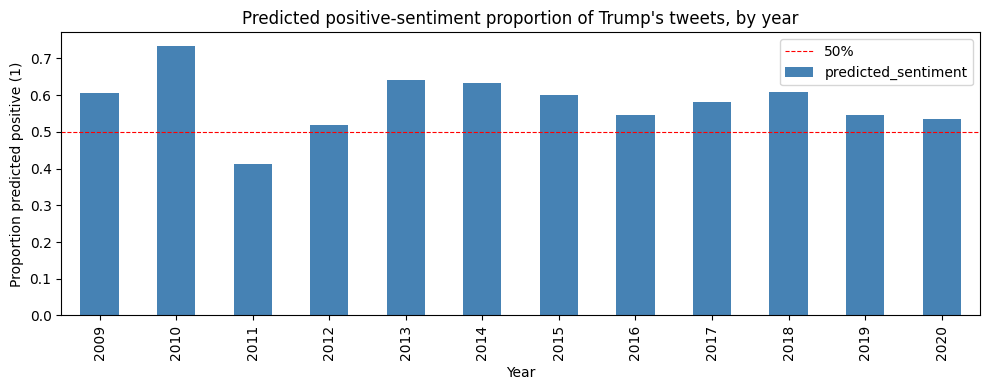

In [21]:
import matplotlib.pyplot as plt

# Convert date column and aggregate by year
df_trump['date'] = pd.to_datetime(df_trump['date'], errors='coerce')
df_trump['year'] = df_trump['date'].dt.year

yearly_sentiment = df_trump.groupby('year')['predicted_sentiment'].mean()

plt.figure(figsize=(10, 4))
yearly_sentiment.plot(kind='bar', color='steelblue')
plt.title("Predicted positive-sentiment proportion of Trump's tweets, by year")
plt.ylabel("Proportion predicted positive (1)")
plt.xlabel("Year")
plt.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='50%')
plt.legend()
plt.tight_layout()
plt.show()